<h1 style="text-align: center;">Physical AI의 Vision-LLM 융합 시청각 멀티모달 시스템</h1>

<br><br>

<div style="text-align: right; color: gray; font-style: italic;">
김규래<br>
kkr.kyurae.kim@gmail.com
</div><br>

---
---


## 6. Vision-LLM 융합 멀티모달 시스템

### A. Vision-to-Text

이번 실습에서는 이전에 배운 YOLO를 활용하여 카메라 영상에서 객체를 탐지하고, 탐지 결과를 Structured Output 형태로 정리합니다.<br>
이후 이를 Natural Language로 변환하여 LLM의 Context로 전달하는 Vision-LLM 파이프라인을 구현해보겠습니다.

* Structured Output
  * BBox, Class, Confidence 등 정해진 형식의 정보
  * 프로그램에서 직접 처리하기 쉬운 형태
* Natural Language
  * 탐지 결과를 사람이 이해할 수 있는 문장으로 표현
  * LLM이 상황을 해석하고 설명하기 쉬운 형태


#### $1)$ YOLO 탐지 결과 구조

우선, YOLO의 탐지 결과를 확인해보도록 하겠습니다.

Loading src/models/YOLO/yolo11n_int8.engine for TensorRT inference...
[08/28/2026-14:07:38] [TRT] [I] Loaded engine size: 5 MiB
[08/28/2026-14:07:38] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[08/28/2026-14:07:39] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +9, now: CPU 0, GPU 11 (MiB)

image 1/1 /home/tim9985/Documents/git/Vision-LLM-JSI/src/images/city.png: 640x640 1 person, 4 cars, 1 fire hydrant, 1 potted plant, 8.6ms
Speed: 61.5ms preprocess, 8.6ms inference, 40.6ms postprocess per image at shape (1, 3, 640, 640)


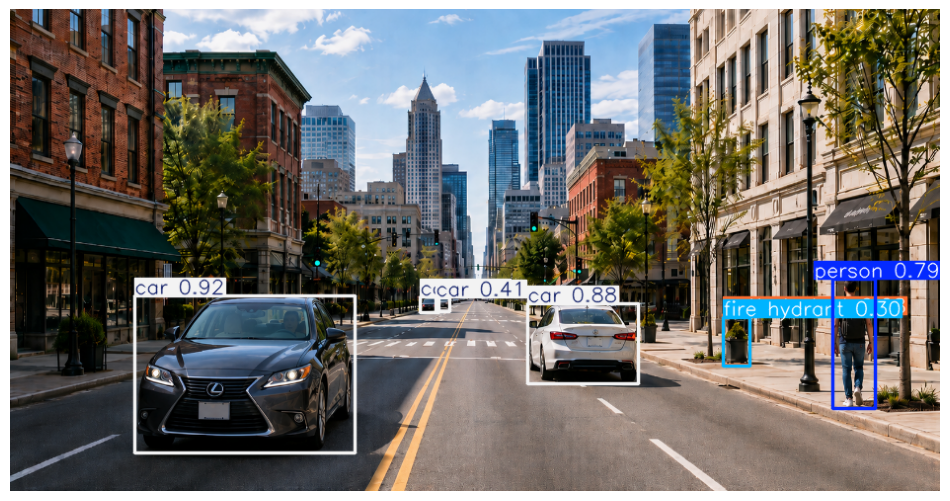

In [1]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


model = YOLO("src/models/YOLO/yolo11n_int8.engine")

results = model.predict(
    source="src/images/city.png",
    conf=0.25,
    iou=0.5,
    classes=None,
)

yolo_test_img = results[0].plot()

yolo_test_img_rgb = cv2.cvtColor(yolo_test_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(yolo_test_img_rgb)
plt.axis("off");

In [2]:
print(results[0].boxes.xyxy)
print(results[0].boxes.conf)
print(results[0].boxes.cls)

tensor([[126.3054, 290.2578, 349.0983, 449.6711],
        [524.4334, 298.8621, 636.1819, 379.3699],
        [833.3607, 273.1080, 876.5075, 404.1101],
        [431.4687, 292.6782, 445.6155, 306.1022],
        [415.1942, 291.4254, 434.5276, 307.3178],
        [722.2353, 312.9593, 749.7126, 361.4511],
        [722.1836, 309.3834, 749.3568, 360.1631]], device='cuda:0')
tensor([0.9178, 0.8798, 0.7903, 0.4110, 0.3881, 0.2958, 0.2799], device='cuda:0')
tensor([ 2.,  2.,  0.,  2.,  2., 10., 58.], device='cuda:0')


#### $2)$ YOLO 결과를 JSON 구조로 변환

원하는 구조:
```python
{
    "image_width": 1280,
    "image_height": 720,
    "objects": [
        {
            "class": "person",
            "confidence": 0.92,
            "bbox": {
                "x1": 100,
                "y1": 80,
                "x2": 450,
                "y2": 700
            }
        }
    ]
}
```

In [3]:
from ultralytics import YOLO
import cv2
import json


model = YOLO("src/models/YOLO/yolo11n_int8.engine")


image = cv2.imread("src/images/city.png")

height, width = image.shape[:2]

results = model.predict(
    source=image,
    conf=0.25,
    iou=0.5,
    verbose=False,
)

result = results[0]


objects = []

for box in result.boxes:
    class_id = int(box.cls[0].item())
    confidence = float(box.conf[0].item())
    x1, y1, x2, y2 = (box.xyxy[0].cpu().tolist())

    objects.append(
        {
            "class": result.names[class_id],
            "confidence": round(confidence, 3),
            "bbox": {
                "x1": int(x1),
                "y1": int(y1),
                "x2": int(x2),
                "y2": int(y2),
            }
        }
    )


vision_dict = {
    "image_width": width,
    "image_height": height,
    "objects": objects,
}

vision_json = json.dumps(vision_dict, ensure_ascii=False, indent=4)


print(vision_json)

Loading src/models/YOLO/yolo11n_int8.engine for TensorRT inference...
[08/28/2026-14:07:42] [TRT] [I] Loaded engine size: 5 MiB
[08/28/2026-14:07:42] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[08/28/2026-14:07:42] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +9, now: CPU 0, GPU 11 (MiB)
{
    "image_width": 942,
    "image_height": 488,
    "objects": [
        {
            "class": "car",
            "confidence": 0.918,
            "bbox": {
                "x1": 126,
                "y1": 290,
                "x2": 349,
                "y2": 449
            }
        },
        {
            "class": "car",
            "confidence": 0.88,
            "bbox": {
                "x1": 524,
                "y1": 298,
                "x2": 636,
                "y2": 379
            }
        },
        {
            "class": "pers

#### $3)$ JSON 저장

In [5]:
with open("src/output/vision_data.json", "w", encoding="utf-8") as file:
    json.dump(vision_dict, file, ensure_ascii=False, indent=4)

print("JSON 파일 저장 완료!")

JSON 파일 저장 완료!


#### $4)$ JSON - 자연어 변환

이제 저장된 JSON 파일을 읽어 LLM이 해석하기 쉬운 형태로 변환합니다.<br>
단순한 template을 사용하여 자연어 문장으로 바꿔봅시다.

단순 Template:

```text
1번 객체는 car이며, confidence는 0.93입니다.
2번 객체는 car이며, confidence는 0.88입니다.
3번 객체는 person이며, confidence는 0.81입니다.
.
.
.
```

In [6]:
def detections_to_text(json_path):
    with open(json_path, "r", encoding="utf-8") as file:
        vision_data = json.load(file)
        
    objects = vision_data["objects"]

    if len(objects) == 0:
        return "현재 탐지된 객체가 없습니다."

    sentences = []

    for index, obj in enumerate(objects, start=1):
        sentence = f"{index}번 객체는 {obj['class']}이며, confidence는 {obj['confidence']:.2f}입니다."

        sentences.append(sentence)

    return "\n".join(sentences)

In [7]:
vision_text = detections_to_text("src/output/vision_data.json")

print(vision_text)

1번 객체는 car이며, confidence는 0.92입니다.
2번 객체는 car이며, confidence는 0.88입니다.
3번 객체는 person이며, confidence는 0.79입니다.
4번 객체는 car이며, confidence는 0.41입니다.
5번 객체는 car이며, confidence는 0.39입니다.
6번 객체는 fire hydrant이며, confidence는 0.30입니다.
7번 객체는 potted plant이며, confidence는 0.28입니다.


#### $5)$ JSON - LLM 연결

JSON 구조를 통해 자연어로 변환된 Vision 결과를 이전 섹션에서 배운 Context로써 Prompt에 추가하여 LLM에 전달합니다.

```text
예시:

Instruction:
주어진 객체 탐지 정보를 바탕으로 현재 상황을 설명하시오.

Context:
1번 객체는 car이며, confidence는 0.93입니다.
2번 객체는 car이며, confidence는 0.88입니다.
3번 객체는 person이며, confidence는 0.81입니다.
4번 객체는 car이며, confidence는 0.41입니다.
5번 객체는 car이며, confidence는 0.40입니다.
6번 객체는 potted plant이며, confidence는 0.38입니다.

Constraint:
탐지 결과에 없는 객체를 추측하지 마시오.

Output Format:
한국어 두 문장 이내.
```

In [ ]:
# TODO: JSON 파일을 사용하여 LLM에 context 전달
# message = [
#     {
#         "role" : "user",
#         "content" : vision_text,
#     }
# ]

# TODO: JSON 파일을 사용하여 LLM에 context 전달


from llama_cpp import Llama


MODEL_PATH = "src/models/Gemma4/google_gemma-4-E2B-it-Q4_K_M.gguf"
CONTEXT_WINDOW = 2048
MAX_TOKENS = 150

vision_text = detections_to_text("src/output/vision_data.json")

llm = Llama(
    model_path=MODEL_PATH,
    n_gpu_layers=-1,
    n_ctx=CONTEXT_WINDOW,
    n_batch=32,
    n_ubatch=32,
    verbose=False,
)

response = llm.create_chat_completion(
    messages=[
        {
            "role": "system",
            "content": """
                        Instruction:
                        주어진 객체 탐지 정보를 바탕으로 현재 상황을 설명하시오.

                        Constraint:
                        탐지 결과에 없는 객체를 추측하지 마시오.

                        Output Format:
                        한국어 두 문장 이내.
                       """
        },
        {
            "role": "user",
            "content": f"""
                        Context:
                        {vision_text}
                       """
        }
    ],
    max_tokens=MAX_TOKENS,
    temperature=0.7
)


print(response["choices"][0]["message"]["content"])

#### $6)$ Vision-LLM 파이프라인 구현

이제 위 방법을 사용하여 실시간 카메라 피드를 받아 현재 프레임의 탐지 결과를 JSON 구조로 LLM에게 전달하는 Vision-LLM 파이프라인을 구현해봅시다.

In [1]:
# TODO: 카메라를 연결하여 LLM에 Vision Context 전달
# TODO: 실시간 프레임 처리 Loop에서 특정 이벤트(예: if key == ord("l"))를 통해 LLM에 Vision Context 전달

# [ANSWER] 카메라 프레임 전체 화면의 YOLO 탐지 결과를 Dictionary → JSON → Natural Language → Gemma 순서로 전달

import cv2
import json

from ultralytics import YOLO
from llama_cpp import Llama


YOLO_MODEL_PATH = "src/models/YOLO/yolo11n_int8.engine"
GEMMA_MODEL_PATH = "src/models/Gemma4/google_gemma-4-E2B-it-Q4_K_M.gguf"
JSON_PATH = "src/output/vision_data.json"

CONTEXT_WINDOW = 2048
MAX_TOKENS = 150


def detections_to_text(json_path):
    with open(json_path, "r", encoding="utf-8") as file:
        vision_data = json.load(file)
        
    objects = vision_data["objects"]

    if len(objects) == 0:
        return "현재 탐지된 객체가 없습니다."

    sentences = []

    for index, obj in enumerate(objects, start=1):
        sentence = f"{index}번 객체는 {obj['class']}이며, confidence는 {obj['confidence']:.2f}입니다."

        sentences.append(sentence)

    return "\n".join(sentences)


yolo = YOLO(YOLO_MODEL_PATH)

llm = Llama(
    model_path=GEMMA_MODEL_PATH,
    n_gpu_layers=-1,
    n_ctx=CONTEXT_WINDOW,
    n_batch=32,
    n_ubatch=32,
    verbose=False,
)

pipeline = (
    "nvarguscamerasrc sensor-id=0 ! "
    "video/x-raw(memory:NVMM), "
    "width=1280, height=720, framerate=30/1 ! "
    "nvvidconv ! "
    "video/x-raw, format=BGRx ! "
    "videoconvert ! "
    "video/x-raw, format=BGR ! "
    "queue leaky=downstream max-size-buffers=1 ! "
    "appsink drop=true max-buffers=1 sync=false"
)

cap = cv2.VideoCapture(pipeline, cv2.CAP_GSTREAMER)


if not cap.isOpened():
    print("카메라를 열 수 없습니다.")
    exit()


print("q : 종료")
print("l : 현재 YOLO 탐지 결과를 Gemma에게 전달")


while True:
    ret, frame = cap.read()
    key = cv2.waitKey(1) & 0xFF

    if not ret:
        break
    if key == ord("q"):
        break

    height, width = frame.shape[:2]


    # 1. 현재 프레임 YOLO 탐지
    results = yolo.predict(
        source=frame,
        conf=0.25,
        iou=0.5,
        verbose=False,
    )

    result = results[0]


    # 2. YOLO 결과 화면 출력
    output_frame = result.plot()
    cv2.imshow("YOLO + Gemma", output_frame)


    # 3. YOLO 탐지 결과를 Dictionary 형태로 변환
    objects = []

    for box in result.boxes:
        class_id = int(box.cls[0].item())
        confidence = float(box.conf[0].item())
        x1, y1, x2, y2 = box.xyxy[0].cpu().tolist()

        objects.append(
            {
                "class": result.names[class_id],
                "confidence": round(confidence, 3),
                "bbox": {
                    "x1": int(x1),
                    "y1": int(y1),
                    "x2": int(x2),
                    "y2": int(y2),
                }
            }
        )

    vision_dict = {
        "image_width": width,
        "image_height": height,
        "objects": objects,
    }


    # 4. Dictionary → JSON 파일 저장
    if key == ord("l"):
        with open(JSON_PATH, "w", encoding="utf-8") as file:
            json.dump(vision_dict, file, ensure_ascii=False, indent=4)
        
        print("\n[JSON 파일 저장 완료]")

        # 5. JSON 파일 → Natural Language 변환
        vision_text = detections_to_text(JSON_PATH)
        print("\n[Vision Context]")
        print(vision_text)

        # 6. 탐지 결과를 Gemma에 Context로 전달
        response = llm.create_chat_completion(
            messages=[
                {
                    "role": "system",
                    "content": """
                                Instruction:
                                주어진 객체 탐지 정보를 바탕으로 현재 상황을 설명하시오.

                                Constraint:
                                탐지 결과에 없는 객체를 추측하지 마시오.

                                Output Format:
                                한국어 두 문장 이내.
                               """
                },
                {
                    "role": "user",
                    "content": f"""
                                Context:
                                {vision_text}
                               """
                },
            ],
            max_tokens=MAX_TOKENS,
            temperature=0.7,
        )

        answer = response["choices"][0]["message"]["content"]

        print("\n[Gemma]")
        print(answer)


cap.release()
cv2.destroyAllWindows()

llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512


GST_ARGUS: Creating output stream
CONSUMER: Waiting until producer is connected...
GST_ARGUS: Available Sensor modes :
GST_ARGUS: 3280 x 2464 FR = 21.000000 fps Duration = 47619048 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 3280 x 1848 FR = 28.000001 fps Duration = 35714284 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1920 x 1080 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1640 x 1232 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 59.999999 fps Duration = 16666667 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: Running with following settings:
   Camera index = 0 
   Camera mode  = 4 
   Output Stream W = 1280 H = 7

[ WARN:0@14.692] global cap_gstreamer.cpp:1728 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


[08/28/2026-14:25:07] [TRT] [I] Loaded engine size: 5 MiB
[08/28/2026-14:25:07] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[08/28/2026-14:25:07] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +9, now: CPU 0, GPU 11 (MiB)


Gtk-Message: 14:25:10.910: Failed to load module "canberra-gtk-module"



[JSON 파일 저장 완료]

[Vision Context]
1번 객체는 person이며, confidence는 0.90입니다.

[Gemma]
주어진 탐지 결과에 따르면, 현재 상황에는 신뢰도 0.90으로 '사람(person)'이 하나 탐지되었습니다. 이 정보만으로는 더 구체적인 상황을 파악하기 어렵습니다.

[JSON 파일 저장 완료]

[Vision Context]
1번 객체는 person이며, confidence는 0.68입니다.
2번 객체는 person이며, confidence는 0.43입니다.
3번 객체는 donut이며, confidence는 0.25입니다.

[Gemma]
현재 상황은 사람 두 명이 감지되었으며, 그중 한 명에 대한 신뢰도는 0.68, 다른 한 명에 대한 신뢰도는 0.43입니다. 또한, 도넛 하나가 낮은 신뢰도(0.25)로 감지되었습니다.

[JSON 파일 저장 완료]

[Vision Context]
1번 객체는 cell phone이며, confidence는 0.91입니다.
2번 객체는 person이며, confidence는 0.90입니다.
3번 객체는 person이며, confidence는 0.76입니다.
4번 객체는 cup이며, confidence는 0.33입니다.

[Gemma]
이미지에는 확신도 0.91의 휴대폰과 확신도 0.90의 사람, 확신도 0.76의 또 다른 사람이 탐지되었습니다. 또한, 확신도 0.33의 컵도 탐지되었습니다.
GST_ARGUS: Cleaning up
CONSUMER: Done Success
GST_ARGUS: Done Success


```python
import cv2
import json

from ultralytics import YOLO
from llama_cpp import Llama


YOLO_MODEL_PATH = "src/models/YOLO/yolo11n_int8.engine"
GEMMA_MODEL_PATH = "src/models/Gemma4/google_gemma-4-E2B-it-Q4_K_M.gguf"
JSON_PATH = "src/output/vision_data.json"

CONTEXT_WINDOW = 2048
MAX_TOKENS = 150


yolo = ...
llm = ...
cap = ...


if not cap.isOpened():
    print("카메라를 열 수 없습니다.")
    exit()


print("q : 종료")
print("l : 현재 YOLO 탐지 결과를 Gemma에게 전달")


while True:
    ret, frame = cap.read()
    key = cv2.waitKey(1) & 0xFF

    if not ret:
        break
    if key == ord("q"):
        break


    # 1. 현재 프레임 YOLO 탐지
    results = yolo.predict(
        source=frame,
        conf=0.25,
        iou=0.5,
        verbose=False,
    )

    result = results[0]


    # 2. YOLO 결과 화면 출력
    output_frame = result.plot()
    cv2.imshow("YOLO + Gemma", output_frame)


    # TODO: 3. YOLO 탐지 결과를 Dictionary 형태로 변환
    objects = []

    for _ in _:
        objects.append(...)

    vision_dict = ...

    
    if key == ord("l"):
        # TODO: 4. Dictionary → JSON 파일 저장
        with ...:
            json.dump(...)
            
        # TODO: 5. JSON 파일 → Natural Language 변환
        vision_text = ...

        # TODO: 6. 탐지 결과를 Gemma에 Context로 전달
        response = ...


cap.release()
cv2.destroyAllWindows()
```

#### $7)$ Vision-LLM 파이프라인 분리 구현

앞선 실습에서는 YOLO와 Gemma를 하나의 Python 프로그램에서 실행했습니다.

Vision과 LLM 두 모델을 하나의 프로세스에서 순차적으로 실행하면, LLM 추론이 진행되는 동안 새로운 카메라 프레임과 객체 탐지 결과를 처리하지 못해 실시간 환경의 최신 정보를 놓칠 수 있습니다.

또한 LLM 처리 지연이나 오류가 Vision 처리까지 함께 영향을 줄 수 있으므로, 실제 실시간 시스템에서는 각 기능을 독립적인 프로세스로 분리하는 것이 더 안정적입니다.

이번 실습에서는 위 과정을 2개의 독립된 프로세스로 각각 실행하고, JSON 파일을 통해 탐지 정보를 전달하는 구조를 구현합니다.

In [18]:
# TODO: 카메라를 연결하여 탐지 결과를 JSON 파일로 저장하는 첫 번째 .py 파일 작성

```python
import cv2
import json
import os

from ultralytics import YOLO
from llama_cpp import Llama


YOLO_MODEL_PATH = "src/models/YOLO/yolo11n_int8.engine"
JSON_PATH = "src/output/vision_data.json"
TEMP_JSON_PATH = "src/output/vision_data_tmp.json"


yolo = ...
cap = ...


if not cap.isOpened():
    print("카메라를 열 수 없습니다.")
    exit()


print("q : 종료")
print("l : 현재 YOLO 탐지 결과를 Gemma에게 전달")


while True:
    ret, frame = cap.read()
    key = cv2.waitKey(1) & 0xFF

    if not ret:
        break
    if key == ord("q"):
        break


    # 1. 현재 프레임 YOLO 탐지
    results = yolo.predict(
        source=frame,
        conf=0.25,
        iou=0.5,
        verbose=False,
    )

    result = results[0]


    # 2. YOLO 결과 화면 출력
    output_frame = result.plot()
    cv2.imshow("YOLO + Gemma", output_frame)


    # TODO: 3. YOLO 탐지 결과를 Dictionary 형태로 변환
    objects = []

    for _ in _:
        objects.append(...)

    vision_dict = ...

    
    if key == ord("l"):
        # TODO: 4. Dictionary → JSON 파일 저장 (임시 파일로 저장)
        with ...:
            json.dump(...)
        
        # 5. 임시 파일 작성 완료 후 실제 파일로 교체
        os.replace(TEMP_JSON_PATH, JSON_PATH)


cap.release()
cv2.destroyAllWindows()
```

In [19]:
# TODO: 저장된 JSON 파일을 읽어 LLM에 전달하는 두 번째 .py 파일 작성

```python
import json
import os
import time

from llama_cpp import Llama


GEMMA_MODEL_PATH = "src/models/Gemma4/google_gemma-4-E2B-it-Q4_K_M.gguf"
JSON_PATH = "src/output/vision_data.json"

CONTEXT_WINDOW = 2048
MAX_TOKENS = 150


llm = ...


print("Vision JSON 입력 대기 중...")


# 파일이 마지막으로 수정된 시간 저장
if os.path.exists(JSON_PATH):
    last_modified = os.path.getmtime(JSON_PATH)
else:
    last_modified = 0


while True:
    # JSON 파일 존재 확인
    if os.path.exists(JSON_PATH):
        current_modified = os.path.getmtime(JSON_PATH)

        # JSON 파일이 수정되었는지 확인
        if current_modified != last_modified:
            last_modified = current_modified

            # TODO: 1. JSON 파일 → Natural Language 변환
            vision_text = ...

            # TODO: 2. 탐지 결과를 Gemma에 Context로 전달
            response = ...
            answer = ...

            print("\n[Gemma]")
            print(answer)
            

    # CPU를 불필요하게 계속 사용하지 않도록 잠시 대기
    time.sleep(0.1)
```

---

### B. Image 기반 Vision-Language 멀티모달 시스템

앞선 실습에서는 YOLO의 객체 탐지 결과를 텍스트로 변환하여 Gemma에 전달했습니다.

이번 실습에서는 이미지와 텍스트라는 서로 다른 모달리티를 함께 입력하여, 카메라 프레임 또는 YOLO Bounding Box 이미지와 텍스트 지시사항을 Gemma가 동시에 처리하는 Vision-Language 멀티모달 시스템을 구현해보겠습니다.

* 모달리티 (Modality)
  * 정보를 표현하고 입력하는 데이터의 형태
  * Text, Image, Audio, Video 등
* 멀티모달 (Multimodal)
  * 서로 다른 두 가지 이상의 Modality를 함께 처리
  * 예: Image + Text를 함께 입력하여 상황 이해 및 응답 생성


#### $1)$ 멀티모달 시스템 확인

우선 이미지 한 장을 LLM에 전달하여 멀티모달 시스템을 확인해봅시다.

이전 섹션에서 미리 다운로드한 멀티모달 모델인 `mmproj` 파일을 사용하여 이미지를 Gemma에 전달합니다.

```python
import cv2
import base64

from llama_cpp import Llama
from llama_cpp.llama_chat_format import Gemma4ChatHandler


MODEL_PATH = "src/models/Gemma4/google_gemma-4-E2B-it-Q4_K_M.gguf"
MMPROJ_PATH = "src/models/Gemma4/mmproj-google_gemma-4-E2B-it-f16.gguf"
IMAGE_PATH = "src/images/city.png"

CONTEXT_WINDOW = 2048
MAX_TOKENS = 150


chat_handler = Gemma4ChatHandler(clip_model_path=MMPROJ_PATH)

llm = Llama(
    model_path=MODEL_PATH,
    chat_handler=chat_handler,
    n_gpu_layers=-1,
    n_ctx=CONTEXT_WINDOW,
    n_batch=32,
    n_ubatch=32,
    verbose=False,
)


image = cv2.imread(IMAGE_PATH)
success, buffer = cv2.imencode(".jpg", image)

if not success:
    raise RuntimeError("이미지 인코딩에 실패했습니다.")

image_base64 = base64.b64encode(buffer).decode("utf-8")
image_data = ("data:image/jpeg;base64," + image_base64)


response = llm.create_chat_completion(
    messages=[
        {
            "role": "system",
            "content": """
                        Instruction:
                        주어진 이미지를 바탕으로 현재 상황을 설명하시오.

                        Constraint:
                        이미지에서 명확하게 확인되지 않는 내용은 추측하지 마시오.

                        Output Format:
                        한국어 두 문장 이내.
                       """
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": (
                        "현재 카메라 이미지를 설명하시오."
                    ),
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": image_data
                    },
                },
            ],
        }
    ],
    max_tokens=MAX_TOKENS,
    temperature=0.7,
)


print(response["choices"][0]["message"]["content"])
```

#### $2)$ ROI 전달

이번에는 특정 ROI만 선택하여 Gemma에 전달합니다.

YOLO 탐지 결과 중 이미지 내 신호등을 crop하여 현재 신호를 설명하도록 하겠습니다.

```python
import cv2
import base64

from ultralytics import YOLO
from llama_cpp import Llama
from llama_cpp.llama_chat_format import Gemma4ChatHandler


YOLO_MODEL_PATH = "src/models/YOLO/yolo11n_int8.engine"
GEMMA_MODEL_PATH = "src/models/Gemma4/google_gemma-4-E2B-it-Q4_K_M.gguf"
MMPROJ_PATH = "src/models/Gemma4/mmproj-google_gemma-4-E2B-it-f16.gguf"
IMAGE_PATH = "src/images/city.png"

CONTEXT_WINDOW = 2048
MAX_TOKENS = 20
DISPLAY_WIDTH = 600
DISPLAY_HEIGHT = 600


yolo = YOLO(YOLO_MODEL_PATH)

chat_handler = Gemma4ChatHandler(clip_model_path=MMPROJ_PATH)

llm = Llama(
    model_path=GEMMA_MODEL_PATH,
    chat_handler=chat_handler,
    n_gpu_layers=-1,
    n_ctx=CONTEXT_WINDOW,
    n_batch=32,
    n_ubatch=32,
    verbose=False,
)


image = cv2.imread(IMAGE_PATH)

if image is None:
    raise RuntimeError("이미지를 불러올 수 없습니다.")


results = yolo.predict(
    source=image,
    conf=0.015,
    iou=0.5,
    classes=[9],
    verbose=False,
)

result = results[0]


if len(result.boxes) == 0:
    raise RuntimeError("신호등이 탐지되지 않았습니다.")


selected_box = min(result.boxes, key=lambda box: float(box.xyxy[0][1].item()))
confidence = float(selected_box.conf[0].item())
x1, y1, x2, y2 = (selected_box.xyxy[0].cpu().tolist())

x1 = int(x1)
y1 = int(y1)
x2 = int(x2)
y2 = int(y2)


height, width = image.shape[:2]

x1 = max(0, x1)
y1 = max(0, y1)
x2 = min(width, x2)
y2 = min(height, y2)

traffic_light_image = image[y1:y2, x1:x2].copy()

if traffic_light_image.size == 0:
    raise RuntimeError("BBox 이미지를 만들 수 없습니다.")


display_image = cv2.resize(traffic_light_image, (DISPLAY_WIDTH, DISPLAY_HEIGHT), interpolation=cv2.INTER_NEAREST)

cv2.namedWindow("Traffic Light", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Traffic Light", DISPLAY_WIDTH, DISPLAY_HEIGHT)
cv2.imshow("Traffic Light", display_image)

while True:
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cv2.destroyWindow("Traffic Light")


success, buffer = cv2.imencode(".jpg", traffic_light_image)

if not success:
    raise RuntimeError("이미지 인코딩에 실패했습니다.")

image_base64 = base64.b64encode(buffer).decode("utf-8")
image_data = "data:image/jpeg;base64," + image_base64


response = llm.create_chat_completion(
    messages=[
        {
            "role": "system",
            "content": """
                        Instruction:
                        주어진 신호등 이미지의 현재 색을 판단하시오.

                        Constraint:
                        반드시 다음 세 가지 중 하나만 대답하시오.
                        빨간불
                        노란불
                        파란불

                        다른 설명이나 문장을 추가하지 마시오.

                        Output Format:
                        한 단어.
                       """
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": (
                        "현재 신호등의 색을 판단하시오."
                    ),
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": image_data
                    },
                },
            ],
        }
    ],
    max_tokens=MAX_TOKENS,
    temperature=0.0,
)


answer = response["choices"][0]["message"]["content"].strip()

print("\n[Gemma]")
print(answer)
```

#### $3)$ Image 기반 Vision-LLM 파이프라인 분리 구현

 이전에 Vision과 LLM을 서로 다른 프로세스로 분리하고 JSON 파일을 통해 객체 탐지 정보를 텍스트로 전달한 것과 같이, 이번에는 같은 구조를 이미지 기반으로 확장하여 YOLO로 선택한 ROI 이미지를 파일로 저장하고 별도 코드에서 불러와 Gemma에 전달합니다.
 
 이를 통해 구조화된 텍스트 정보뿐 아니라 실제 이미지 자체를 프로세스 간에 전달하는 Vision-Language 파이프라인을 구현해보겠습니다.

##### ROI 이미지 저장 코드:

```python
import cv2
import os

from ultralytics import YOLO


YOLO_MODEL_PATH = "src/models/YOLO/yolo11n_int8.engine"
IMAGE_PATH = "src/images/city.png"
OUTPUT_IMAGE_PATH = "src/output/vision_output.jpg"
TEMP_IMAGE_PATH = "src/output/vision_output_temp.jpg"

DISPLAY_WIDTH = 600
DISPLAY_HEIGHT = 600


yolo = YOLO(YOLO_MODEL_PATH)

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise RuntimeError("이미지를 불러올 수 없습니다.")


results = yolo.predict(
    source=image,
    conf=0.015,
    iou=0.5,
    classes=[9],
    verbose=False,
)

result = results[0]


if len(result.boxes) == 0:
    raise RuntimeError("신호등이 탐지되지 않았습니다.")


selected_box = min(result.boxes, key=lambda box: float(box.xyxy[0][1].item()))
confidence = float(selected_box.conf[0].item())
x1, y1, x2, y2 = (selected_box.xyxy[0].cpu().tolist())

x1 = int(x1)
y1 = int(y1)
x2 = int(x2)
y2 = int(y2)


height, width = image.shape[:2]

x1 = max(0, x1)
y1 = max(0, y1)
x2 = min(width, x2)
y2 = min(height, y2)

traffic_light_image = image[y1:y2, x1:x2].copy()

if traffic_light_image.size == 0:
    raise RuntimeError("BBox 이미지를 만들 수 없습니다.")


display_image = cv2.resize(traffic_light_image, (DISPLAY_WIDTH, DISPLAY_HEIGHT), interpolation=cv2.INTER_NEAREST)

cv2.namedWindow("Traffic Light", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Traffic Light", DISPLAY_WIDTH, DISPLAY_HEIGHT)
cv2.imshow("Traffic Light", display_image)


while True:
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cv2.destroyAllWindows()


success = cv2.imwrite(TEMP_IMAGE_PATH, traffic_light_image)

if not success:
    raise RuntimeError("이미지 저장에 실패했습니다.")


os.replace(TEMP_IMAGE_PATH, OUTPUT_IMAGE_PATH)

print(f"\n이미지 저장 완료: {OUTPUT_IMAGE_PATH}")
```

##### 이미지 로드 + Gemma 전달 코드:

```python
import os
import time
import base64

from llama_cpp import Llama
from llama_cpp.llama_chat_format import Gemma4ChatHandler


GEMMA_MODEL_PATH = "src/models/Gemma4/google_gemma-4-E2B-it-Q4_K_M.gguf"
MMPROJ_PATH = "src/models/Gemma4/mmproj-google_gemma-4-E2B-it-f16.gguf"
IMAGE_PATH = "src/output/vision_output.jpg"

CONTEXT_WINDOW = 2048
MAX_TOKENS = 20


chat_handler = Gemma4ChatHandler(clip_model_path=MMPROJ_PATH)

llm = Llama(
    model_path=GEMMA_MODEL_PATH,
    chat_handler=chat_handler,
    n_gpu_layers=-1,
    n_ctx=CONTEXT_WINDOW,
    n_batch=32,
    n_ubatch=32,
    verbose=False,
)


print("Vision JPG 입력 대기 중...")


# 파일이 마지막으로 수정된 시간 저장
if os.path.exists(IMAGE_PATH):
    last_modified = os.path.getmtime(IMAGE_PATH)
else:
    last_modified = 0


while True:
    # 이미지 파일 존재 확인
    if os.path.exists(IMAGE_PATH):
        current_modified = os.path.getmtime(IMAGE_PATH)

        # 이미지 파일이 수정되었는지 확인
        if current_modified != last_modified:
            last_modified = current_modified

            # 이미지 파일 읽기
            with open(IMAGE_PATH, "rb") as file:
                image_bytes = file.read()

            # 이미지 → Base64
            image_base64 = (base64.b64encode(image_bytes).decode("utf-8"))
            image_data = ("data:image/jpeg;base64," + image_base64)

            # 이미지 + 텍스트를 Gemma에 전달
            response = llm.create_chat_completion(
                messages=[
                    {
                        "role": "system",
                        "content": """
                                    Instruction:
                                    주어진 신호등 이미지의 현재 색을 판단하시오.

                                    Constraint:
                                    반드시 다음 세 가지 중 하나만 대답하시오.
                                    빨간불
                                    노란불
                                    파란불

                                    다른 설명이나 문장을 추가하지 마시오.

                                    Output Format:
                                    한 단어.
                                   """
                    },
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "text",
                                "text": (
                                    "현재 신호등의 색을 판단하시오."
                                ),
                            },
                            {
                                "type": "image_url",
                                "image_url": {
                                    "url": image_data
                                },
                            },
                        ],
                    }
                ],
                max_tokens=MAX_TOKENS,
                temperature=0.0,
            )

            answer = response["choices"][0]["message"]["content"].strip()

            print("\n[Gemma]")
            print(answer)


    # CPU를 불필요하게 계속 사용하지 않도록 잠시 대기
    time.sleep(0.1)
```

#### $4)$ 실시간 멀티모달 시스템

이제 정적 이미지 대신 실시간 카메라 피드를 사용하여 현재 프레임을 LLM에 전달하도록 하겠습니다.

In [20]:
# TODO: 카메라 프레임 내 YOLO 감지 객체 하나를 선택하여 이미지로 LLM에 전달

```python
import cv2
import base64

from ultralytics import YOLO
from llama_cpp import Llama
from llama_cpp.llama_chat_format import Gemma4ChatHandler


YOLO_MODEL_PATH = "src/models/YOLO/yolo11n_int8.engine"
GEMMA_MODEL_PATH = "src/models/Gemma4/google_gemma-4-E2B-it-Q4_K_M.gguf"
MMPROJ_PATH = "src/models/Gemma4/mmproj-google_gemma-4-E2B-it-f16.gguf"

CONTEXT_WINDOW = 2048
MAX_TOKENS = 150


yolo = ...
llm = ...
cap = ...

if not cap.isOpened():
    print("카메라를 열 수 없습니다.")
    exit()


print("q : 종료")
print("l : 가장 왼쪽 객체를 Gemma에게 전달")


while True:
    result = ...

    detected_objects = ...
    
    if detected_objects:
        selected_object = min(detected_objects, key=lambda x: x["bbox"][0])


    output_frame = ...
    cv2.imshow("YOLO + Gemma", output_frame)


    if key == ord("l"):
        object_image = ...
        cv2.imshow("Selected Object", object_image)

        image_base64 = ...
        image_data = ...

        response = ...
        answer = ...


cap.release()
cv2.destroyAllWindows()
```

---

### C. STT, TTS

앞선 실습에서는 카메라 프레임과 객체 이미지를 Gemma에 전달하여 Vision-Language 멀티모달 시스템을 구현했습니다.

이제는 사용자가 Prompt를 적는 대신, 음성으로 질문하고 Gemma의 응답도 텍스트가 아닌 음성으로 출력할 수 있도록 STT와 TTS를 연결해보겠습니다.

이번 파트에서는 사용자 음성 → STT → Gemma → TTS → 음성 응답의 전체 음성 기반 상호작용 파이프라인을 구성합니다.

#### $1)$ `Whisper.cpp` 패키지 설치:

우선 STT 패키지인 `Whisper`를 설치합시다.

```bash
git clone https://github.com/ggml-org/whisper.cpp.git
```

```bash
sudo apt install -y cmake
export PATH=/usr/local/cuda-12.6/bin:$PATH
export LD_LIBRARY_PATH=/usr/local/cuda-12.6/lib64:$LD_LIBRARY_PATH
cd whisper.cpp
```

1. CPU 버전으로 빌드:

```bash
cmake -B build-cpu

cmake --build build-cpu --target whisper-cli -j4 --config Release
```

2. CUDA 버전으로 빌드:

```bash
cmake -B build -DGGML_CUDA=1

cmake --build build -j4 --config Release
```

빌드가 끝나면 `whisper-cli` 파일이 생성됩니다.

파일 생성 확인:

CPU:
```bash
ls -lh build-cpu/bin/whisper-cli
```

CUDA:
```bash
ls -lh build/bin/whisper-cli
```

한국어 Whisper 모델 다운로드:

```bash
sh ./models/download-ggml-model.sh base
```

#### 간단한 STT 테스트:

```bash
cd ..
mkdir src/audio
```

5초간 음성 녹음:

```bash
arecord \
    -D plughw:2,0 \
    -f S16_LE \
    -r 16000 \
    -c 1 \
    -d 5 \
    src/audio/input.wav
```

STT 테스트:

```bash
# ./build-cpu/bin/whisper-cli \
#     -m models/ggml-base.bin \
#     -f src/audio/input.wav \
#     -l ko \
#     -nt

 whisper.cpp/build-cpu/bin/whisper-cli     -m whisper.cpp/models/ggml-base.bin     -f src/audio/input.wav     -l ko     -ntD    
```

#### $2)$ `Piper` 패키지 설치:

다음으로는 TTS 패키지인 `Piper`를 설치합시다.

별도 가상환경 생성:

```bash
deactivate
python3 -m venv .piper_venv
source .piper_venv/bin/activate
```

`Piper` 설치:

```bash
pip install piper-tts
```

한국어 음성 다운로드:

```bash
mkdir -p src/models/Piper
python3 -m piper.download_voices \
    ko_KR-kss-medium \
    --data-dir src/models/Piper
```

TTS 테스트:

```bash
python3 -m piper \
    -m src/models/Piper/ko_KR-kss-medium.onnx \
    -f src/audio/response.wav \
    -- \
    "안녕하세요. 반갑습니다."
```

```bash
aplay src/audio/response.wav
```

#### $3)$ Python 환경에서의 STT, TTS

앞서 명령어로 STT와 TTS가 문제 없이 실행되었다면, 이제 Python 코드로 동일한 작업을 수행해보도록 합시다.

#### STT:

```python
import subprocess


MIC_DEVICE = "plughw:3,0"
AUDIO_FILE = "src/audio/input.wav"
WHISPER_PATH = "whisper.cpp/build-cpu/bin/whisper-cli"
WHISPER_MODEL = "whisper.cpp/models/ggml-base.bin"
RECORD_SECONDS = 5


print("말씀을 시작해 주세요.")


subprocess.run(
    [
        "pasuspender", "--",
        "arecord",
        "-D", MIC_DEVICE,
        "-f", "S16_LE",
        "-r", "16000",
        "-c", "1",
        "-d", str(RECORD_SECONDS),
        AUDIO_FILE,
    ],
    check=True,
)

result = subprocess.run(
    [
        WHISPER_PATH,
        "-m", WHISPER_MODEL,
        "-f", AUDIO_FILE,
        "-l", "ko",
        "--no-timestamps",
    ],
    text=True,
    capture_output=True,
    check=True,
)


text = result.stdout.strip()

print("STT 결과:")
print(text)
```

#### TTS:

```python
import subprocess


PIPER_PYTHON = ".piper_venv/bin/python"
PIPER_MODEL = "src/models/Piper/ko_KR-kss-medium.onnx"
OUTPUT_FILE = "src/audio/response.wav"
SPEAKER_DEVICE = "plughw:2,0"


text = "현재는 빨간불입니다. 주의하시길 바랍니다!"

subprocess.run(
    [
        PIPER_PYTHON,
        "-m",
        "piper",

        "-m",
        PIPER_MODEL,

        "-f",
        OUTPUT_FILE,

        "--",
        text,
    ],
    check=True,
)

subprocess.run(
    [
        "aplay",
        "-D",
        SPEAKER_DEVICE,
        OUTPUT_FILE,
    ],
    check=True,
)
```

동일한 코드를 함수로 정의하도록 합시다.

```python
def speech_to_text():
    subprocess.run(
        [
            "pasuspender", "--",
            "arecord",
            "-D", MIC_DEVICE,
            "-f", "S16_LE",
            "-r", "16000",
            "-c", "1",
            "-d", str(RECORD_SECONDS),
            AUDIO_FILE,
        ],
        check=True,
    )

    result = subprocess.run(
        [
            WHISPER_PATH,
            "-m", WHISPER_MODEL,
            "-f", AUDIO_FILE,
            "-l", "ko",
            "--no-timestamps",
        ],
        text=True,
        capture_output=True,
        check=True,
    )


    return result.stdout.strip()
```

```python
def text_to_speech(text):
    subprocess.run(
        [
            PIPER_PYTHON,
            "-m",
            "piper",

            "-m",
            PIPER_MODEL,

            "-f",
            OUTPUT_FILE,

            "--",
            text,
        ],
        check=True,
    )

    subprocess.run(
        [
            "aplay",
            "-D",
            SPEAKER_DEVICE,
            OUTPUT_FILE,
        ],
        check=True,
    )
```

간단한 테스트로 위 함수들을 사용해봅시다.

```python
question = speech_to_text()
print(question)
text_to_speech("앞에 사람이 한 명 있습니다.")
```

STT와 TTS가 정상적으로 작동한다면, Vision 및 LLM 기능과 연결하여 하나의 통합 시스템으로 확장할 수 있습니다.

이를 통해 AI가 사용자와 같은 장면을 바라보고, 사용자의 음성을 이해한 뒤 음성으로 응답하는 시청각 멀티모달 시스템을 구현할 수 있습니다.

이것으로 **『Vision-LLM 융합 멀티모달 시스템』** 섹션을 마무리합니다.

---

## <center>< Final Project ></center>

전 과정에서 다룬 내용을 바탕으로 Vision-LLM 융합 시청각 멀티모달 시스템을 구축합니다.<br>
각 섹션의 메인 주제인 Gemma와 YOLO, 그리고 모든 기법들을 통합하여, 객체를 탐지하고 특정 이벤트를 감지하여 유저 음성 입력을 받아 음성으로 출력하는 파이프라인을 설계합니다.

In [21]:
# TODO: Section 6 "Vision-LLM Multimodal Systems" Project

---
---

<br><br><div style="text-align: right; color: gray; font-style: italic;">
© 2026 김규래 (Kyu Rae Kim). All rights reserved.&emsp;<br><br>
This material is provided solely for the intended instructional purpose.&emsp;<br>
Redistribution, reproduction, modification, adaptation, or reuse of this material in any form without prior written permission from the copyright holder is prohibited.&emsp;
</div>